In [4]:
!pip install xgboost shap imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score
from imblearn.over_sampling import SMOTE
import shap
import pickle
from collections import Counter

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [12]:
df = pd.read_csv("/content/sample_data/creditcard[1].csv")
print("✅ Dataset loaded!")
print("Shape:", df.shape)
print(df.head())

✅ Dataset loaded!
Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.20601

Shape: (284807, 31)

Null Values: 0 (should be 0)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

⚠️ Fraud = only 0.1727% of data
This is why accuracy is MISLEADING for fraud detection!


/tmp/ipykernel_1431/2835973549.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['steelblue','crimson'])


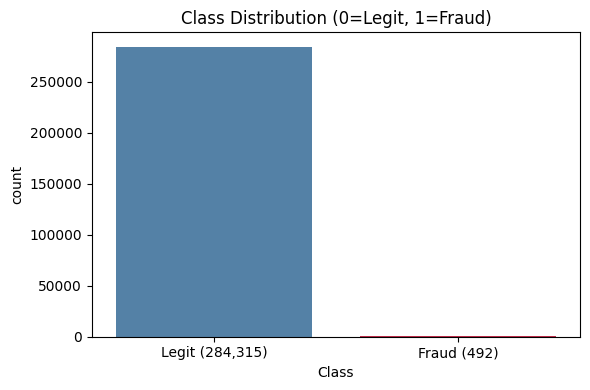


Amount Stats:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


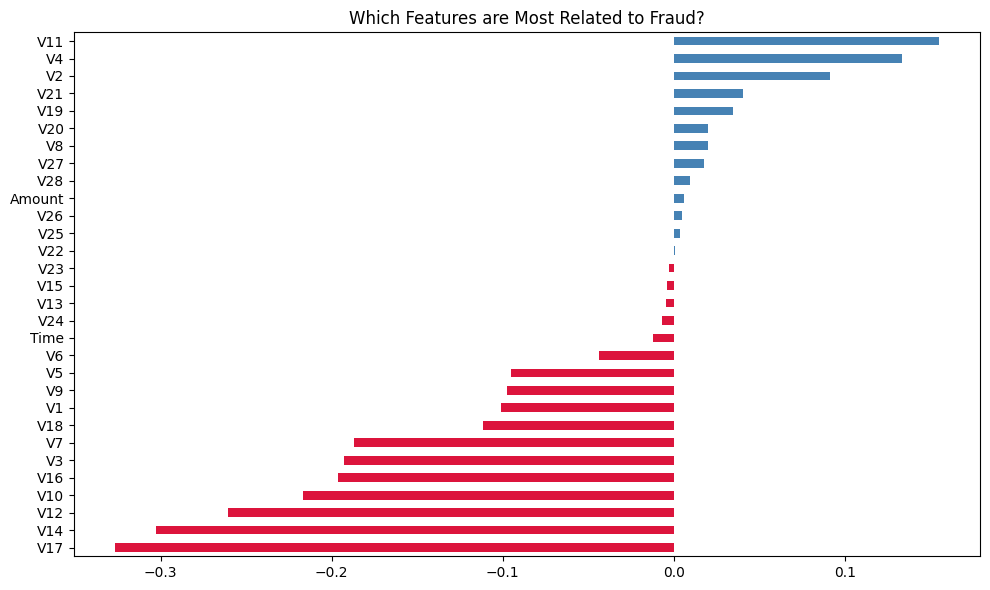


✅ EDA Done! Top fraud indicators:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [13]:
# ── CELL 3: EDA ──────────────────────────────────────────────

# 1. Basic Info
print("Shape:", df.shape)
print("\nNull Values:", df.isnull().sum().sum(), "(should be 0)")
print("\nClass Distribution:")
print(df['Class'].value_counts())

fraud_percent = (df['Class'].sum() / len(df)) * 100
print(f"\n⚠️ Fraud = only {fraud_percent:.4f}% of data")
print("This is why accuracy is MISLEADING for fraud detection!")

# 2. Class Imbalance Chart
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['steelblue','crimson'])
plt.title('Class Distribution (0=Legit, 1=Fraud)')
plt.xticks([0,1], ['Legit (284,315)', 'Fraud (492)'])
plt.tight_layout()
plt.show()

# 3. Amount comparison - fraud vs legit
print("\nAmount Stats:")
print(df.groupby('Class')['Amount'].describe())

# 4. Correlation with fraud
correlations = df.corr()['Class'].drop('Class').sort_values()
plt.figure(figsize=(10,6))
correlations.plot(kind='barh',
    color=['crimson' if x < 0 else 'steelblue' for x in correlations])
plt.title('Which Features are Most Related to Fraud?')
plt.tight_layout()
plt.show()

print("\n✅ EDA Done! Top fraud indicators:")
print(correlations.head(5))  # most negatively correlated

In [14]:
# ── CELL 4: CLEANING + FEATURE ENGINEERING ───────────────────

from sklearn.preprocessing import StandardScaler

# 1. Normalize Amount and Time (different scale than V1-V28)
scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled']   = scaler.fit_transform(df[['Time']])

# 2. Drop original unscaled columns
df_clean = df.drop(['Amount', 'Time'], axis=1)

# 3. New features
df_clean['Amount_Log']   = np.log1p(abs(df_clean['Amount_Scaled']))
df_clean['V14_V17']      = df_clean['V14'] * df_clean['V17']  # interaction term

print("✅ Cleaning done!")
print("New shape:", df_clean.shape)

# 4. Split X and y
X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

print("\nFeatures shape:", X.shape)
print("Fraud count:", y.sum())

# 5. Train/Test Split BEFORE SMOTE (very important!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

# 6. Apply SMOTE only on training data
print("\nBefore SMOTE:", Counter(y_train))
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("After SMOTE:", Counter(y_train_smote))
print("\n✅ Now both classes are equal — model can learn fraud properly!")

✅ Cleaning done!
New shape: (284807, 33)

Features shape: (284807, 32)
Fraud count: 492

Train size: (227845, 32)
Test size: (56962, 32)

Before SMOTE: Counter({0: 227451, 1: 394})
After SMOTE: Counter({0: 227451, 1: 227451})

✅ Now both classes are equal — model can learn fraud properly!


Training models... please wait ⏳
✅ Logistic Regression done
✅ Random Forest done
✅ XGBoost done


📊 Logistic Regression
   AUC-ROC : 0.9718
   F1 Score: 0.0970
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962


📊 Random Forest
   AUC-ROC : 0.9790
   F1 Score: 0.8449
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.89      0.81      0.84        98

    accuracy                           1.00     56962
   macro avg       0.94      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962


📊 XGBoost
   AUC-ROC : 0.9740
   F1 Score: 0.5217
              precision    recall  f1-score   support

       Legit       1.00

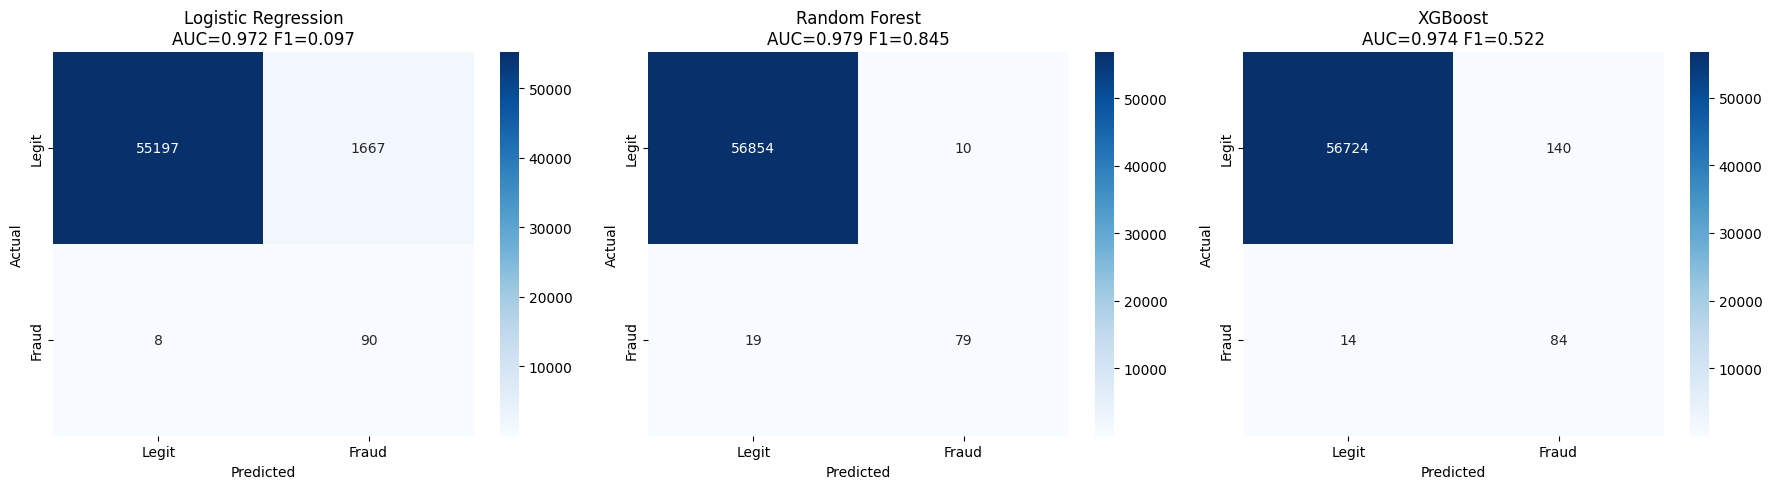

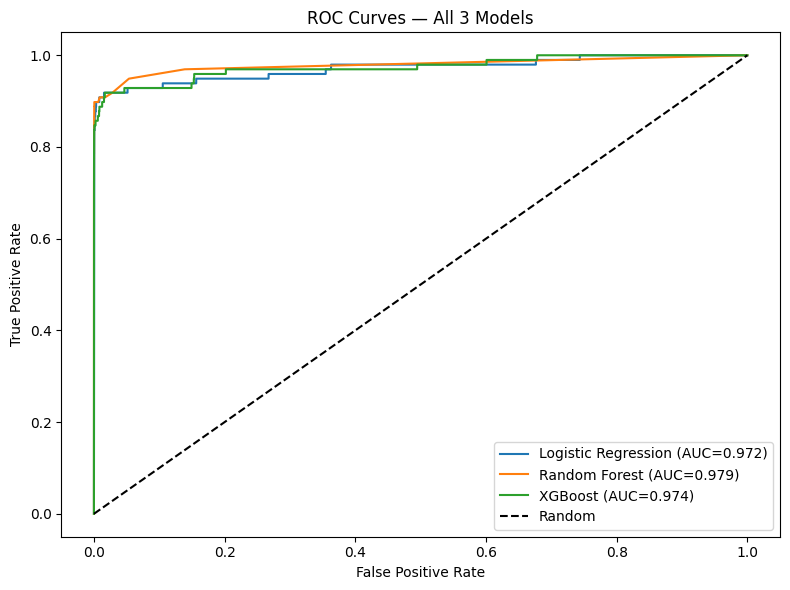


✅ Modeling done!
Best model is usually XGBoost with highest AUC!


In [16]:
# ── CELL 5: MODEL TRAINING + EVALUATION ──────────────────────

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import seaborn as sns

# 1. Train 3 Models
print("Training models... please wait ⏳")

# Model 1 - Logistic Regression (baseline)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)
print("✅ Logistic Regression done")

# Model 2 - Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)
print("✅ Random Forest done")

# Model 3 - XGBoost
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1,
                    max_depth=6, eval_metric='logloss', random_state=42)
xgb.fit(X_train_smote, y_train_smote)
print("✅ XGBoost done")

# 2. Evaluate All Models
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

print("\n" + "="*55)
results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    auc    = roc_auc_score(y_test, y_prob)
    f1     = f1_score(y_test, y_pred)
    results[name] = {"auc": auc, "f1": f1,
                     "y_pred": y_pred, "y_prob": y_prob}
    print(f"\n📊 {name}")
    print(f"   AUC-ROC : {auc:.4f}")
    print(f"   F1 Score: {f1:.4f}")
    print(classification_report(y_test, y_pred,
          target_names=["Legit","Fraud"]))

# 3. Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Legit','Fraud'],
                yticklabels=['Legit','Fraud'])
    ax.set_title(f'{name}\nAUC={res["auc"]:.3f} F1={res["f1"]:.3f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

# 4. ROC Curves
plt.figure(figsize=(8,6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    plt.plot(fpr, tpr, label=f'{name} (AUC={res["auc"]:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All 3 Models')
plt.legend()
plt.tight_layout()
plt.show()

print("\n✅ Modeling done!")
print("Best model is usually XGBoost with highest AUC!")

Computing SHAP values... ⏳ (takes ~1 min)
✅ SHAP values computed!


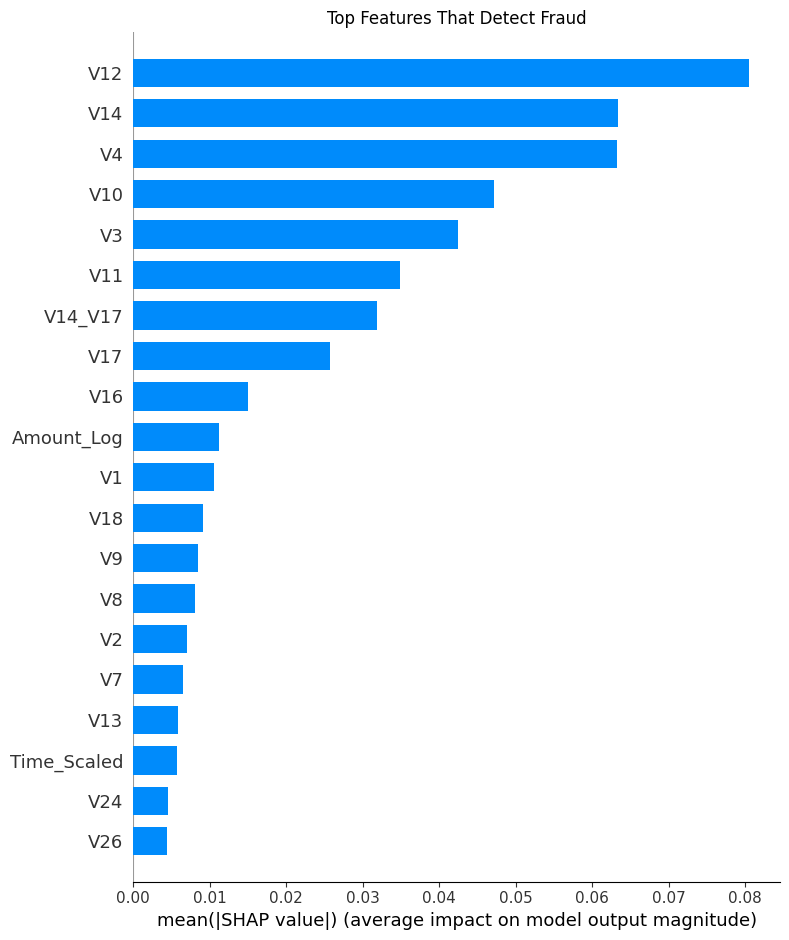

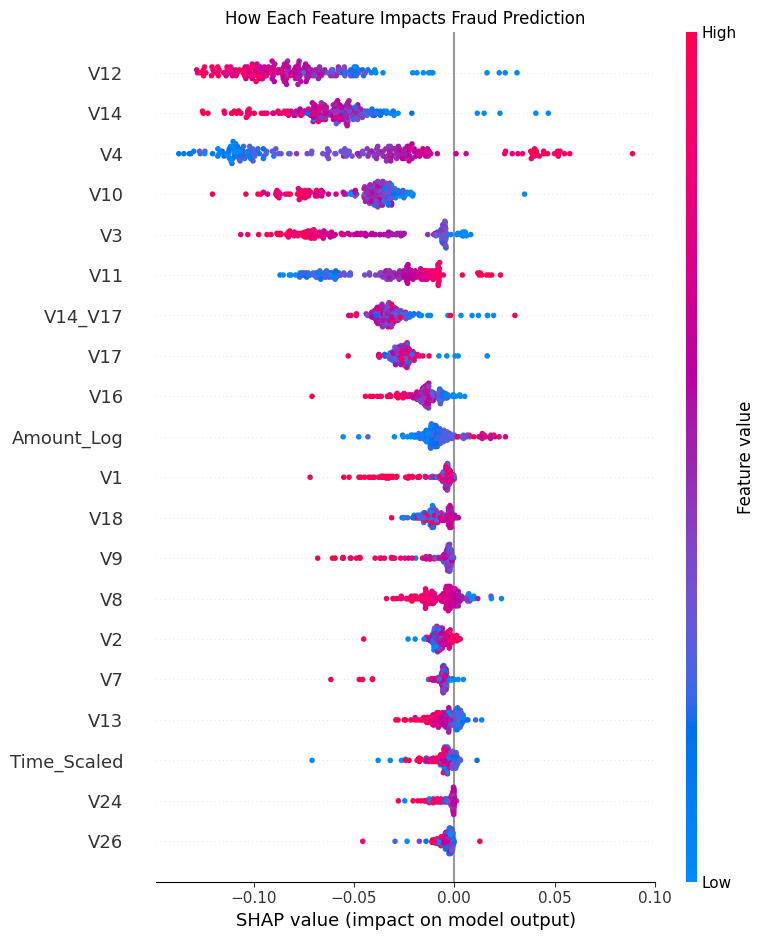


🚨 Explaining why THIS transaction was flagged as fraud:


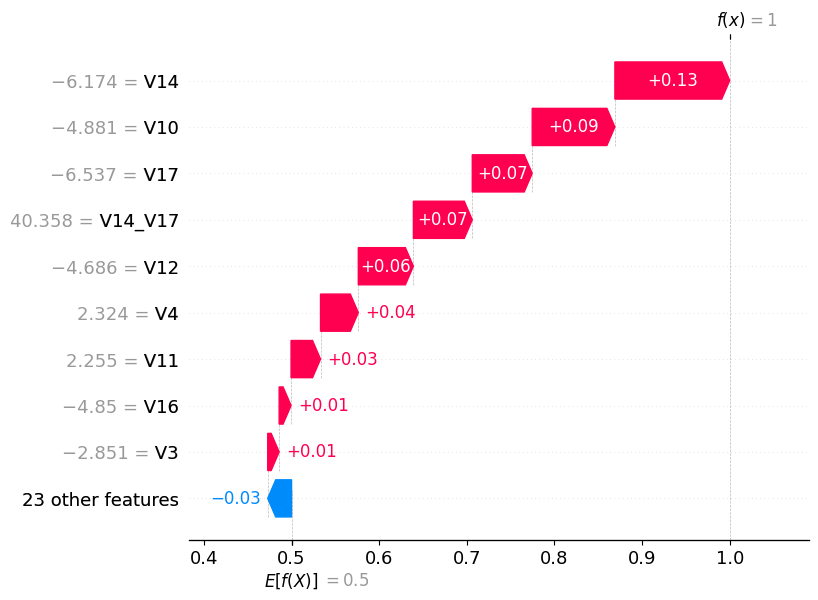


📊 Fraud Probability : 100.0%
   Risk Level        : 🔴 HIGH
   Top Reasons       : ['V14', 'V10', 'V17']

✅ SHAP Done!


In [18]:
# ── CELL 6: SHAP EXPLAINABILITY ───────────────────────────────

!pip install shap -q
import shap

# Use Random Forest (best model)
best_model = rf

# Sample 200 rows (SHAP is slow on full dataset)
X_sample = X_test.sample(200, random_state=42)
print("Computing SHAP values... ⏳ (takes ~1 min)")

explainer  = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

print("✅ SHAP values computed!")

# 1. Global Feature Importance
plt.figure()
shap.summary_plot(shap_values[:,:,1], X_sample,
                  plot_type="bar", show=False)
plt.title("Top Features That Detect Fraud")
plt.tight_layout()
plt.show()

# 2. Beeswarm — direction of impact
plt.figure()
shap.summary_plot(shap_values[:,:,1], X_sample, show=False)
plt.title("How Each Feature Impacts Fraud Prediction")
plt.tight_layout()
plt.show()

# 3. Explain ONE fraud transaction
fraud_idx   = y_test[y_test == 1].index[0]
fraud_trans = X_test.loc[[fraud_idx]]
fraud_shap  = explainer.shap_values(fraud_trans)

print("\n🚨 Explaining why THIS transaction was flagged as fraud:")
shap.waterfall_plot(
    shap.Explanation(
        values        = fraud_shap[:,:,1][0],
        base_values   = explainer.expected_value[1],
        data          = fraud_trans.iloc[0],
        feature_names = X_test.columns.tolist()
    )
)

# 4. Risk scoring function
def get_risk(transaction):
    prob = best_model.predict_proba(transaction)[0][1]
    risk = "🔴 HIGH" if prob > 0.7 else "🟡 MEDIUM" if prob > 0.4 else "🟢 LOW"
    sv   = explainer.shap_values(transaction)
    top3 = pd.Series(sv[:,:,1][0],
           index=transaction.columns).abs().sort_values(ascending=False).head(3)
    print(f"\n📊 Fraud Probability : {prob*100:.1f}%")
    print(f"   Risk Level        : {risk}")
    print(f"   Top Reasons       : {top3.index.tolist()}")

get_risk(fraud_trans)
print("\n✅ SHAP Done!")